# Basic image handling

**Duration** ~45 min &nbsp;·&nbsp; **Session** Day 1, Python notebooks

In the Fiji practical, you analysed these images through the interface. Here you
will repeat the main steps in Python. This makes the operations explicit and
allows the same code to run on several images.

**This notebook covers**

- what an image *is* to a computer, and how to read its shape and data type
- cropping, slicing and indexing, the same way a list is indexed
- displaying images and channels, and building a composite
- reading a histogram, and using it to choose a threshold
- turning an image into a binary image, and a binary image into counted objects

**Data**: `data/bbbc020/` field `2h_1`: mouse bone-marrow macrophages, two
channels.
DAPI stains nuclei; CD11b stains the cell surface. These are the same images
segmented in the Fiji practical.

## 1. An image is an array of numbers

In [1]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt

from course import DATA, show

# The same field you worked on in Fiji.
nuclei = tifffile.imread(DATA / "bbbc020" / "images" / "2h_1_nuclei.tif")

print("type :", type(nuclei))
print("shape:", nuclei.shape)
print("dtype:", nuclei.dtype)
print("range:", nuclei.min(), "to", nuclei.max())

type : <class 'numpy.ndarray'>
shape: (348, 512)
dtype: uint8
range: 0 to 255


Three things to take from that output.

**`shape` is `(rows, columns)`**: 348 rows by 512 columns. Note the order:
height first, then width. This trips up nearly everyone at least once, because
Fiji's status bar reports it the other way round, as *width × height*.

**`dtype` is `uint8`**: an *unsigned 8-bit integer*, so every pixel is a whole
number from 0 to 255. This is the "8-bit" shown in Fiji's `Image ▸ Type` menu.
A 16-bit image (`uint16`) would run 0–65535.

**The image is just a NumPy array.** There is no special image object, so
everything that holds for arrays holds here, and everything in this notebook
transfers to any other numerical data.

In [2]:
# A pixel is one number. Row 187, column 234 lands on background:
print("background pixel (187, 234):", nuclei[187, 234])

# ...and this one lands inside a nucleus.
print("nucleus pixel   (336, 25):", nuclei[336, 25])

background pixel (187, 234): 2
nucleus pixel   (336, 25): 255


## 2. Looking at it

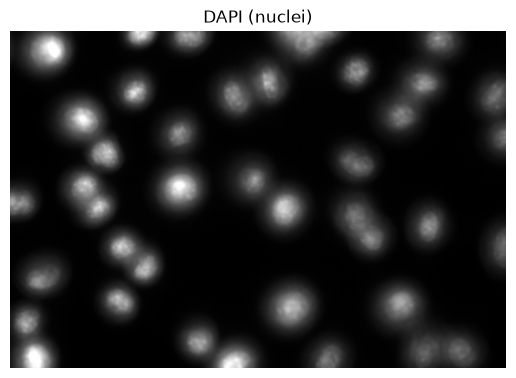

In [3]:
show(nuclei, title="DAPI (nuclei)")
plt.show()

`show()` is a small helper defined in `notebooks/course.py`: it calls
matplotlib's `imshow` with a grayscale colormap and no axis ticks, so we do not
repeat those arguments in every cell. It is worth a look; there is nothing magic
in there.

One thing worth being explicit about: **the colours on screen are a display
choice, not a property of the data.** The array holds one number per pixel. Matplotlib
maps those numbers to colours using a *colormap*. Fiji calls the same thing a
LUT. Changing it changes the picture, never the data.

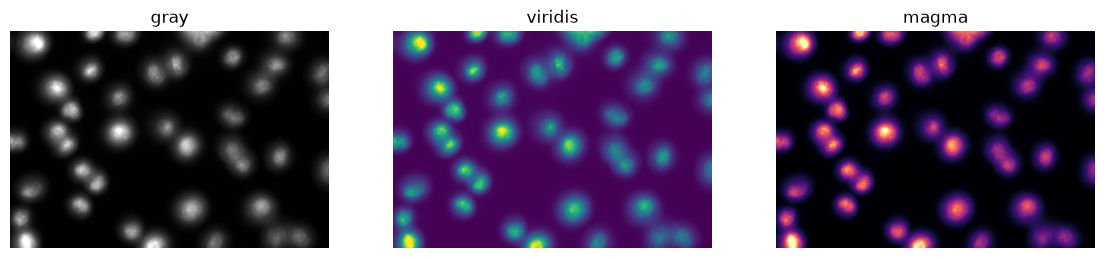

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, cmap in zip(axes, ["gray", "viridis", "magma"]):
    show(nuclei, title=cmap, cmap=cmap, ax=ax)
plt.show()

## 3. Cropping is just indexing

An image is indexed exactly like a nested list: `image[rows, columns]`. A colon
means "all of them", and `start:stop` selects a range.

crop shape: (110, 150)


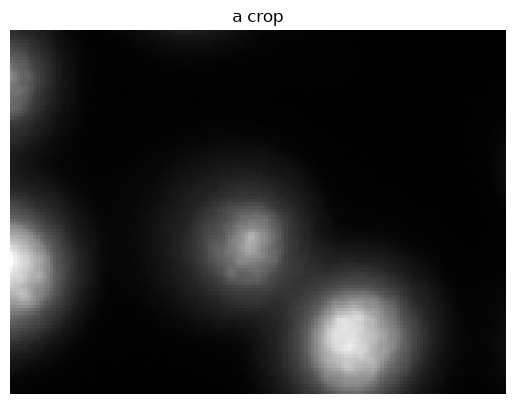

In [5]:
# Rows 90 to 200, columns 180 to 330.
crop = nuclei[90:200, 180:330]
print("crop shape:", crop.shape)

show(crop, title="a crop")
plt.show()

one row: (512,)


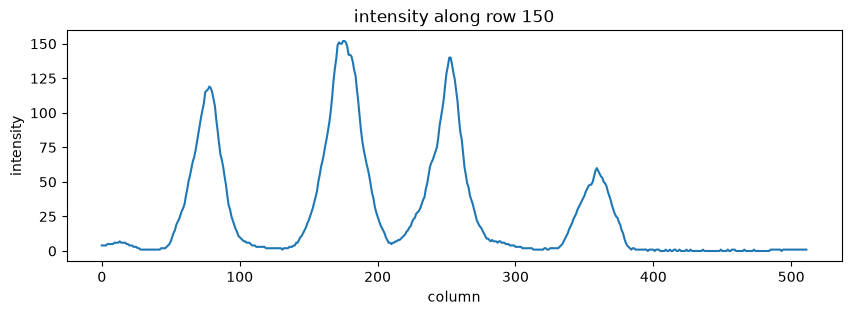

In [6]:
# A single row is a 1D array - this is exactly Fiji's line profile.
row = nuclei[150, :]
print("one row:", row.shape)

plt.figure(figsize=(10, 3))
plt.plot(row)
plt.xlabel("column")
plt.ylabel("intensity")
plt.title("intensity along row 150")
plt.show()

Every peak in that trace is a bright object the line crossed. This is the same
plot Fiji draws for `Analyze ▸ Plot Profile`, and it is the reason the "how wide
is a filament?" exercise works: measuring the peak's width measures the
object.

## 4. Two channels

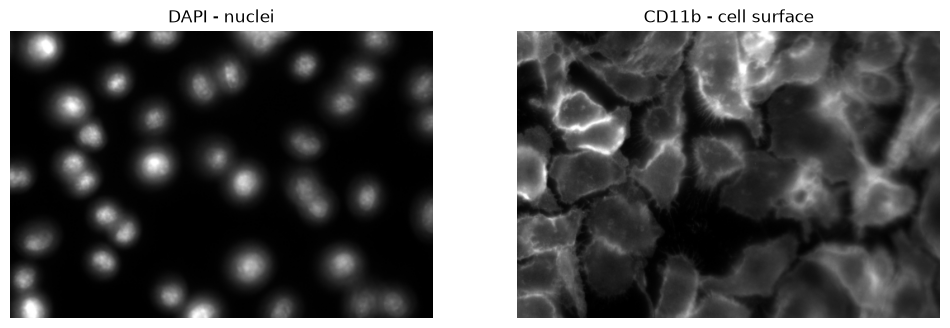

In [7]:
cells = tifffile.imread(DATA / "bbbc020" / "images" / "2h_1_cells.tif")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
show(nuclei, title="DAPI - nuclei", ax=axes[0])
show(cells, title="CD11b - cell surface", ax=axes[1])
plt.show()

These channels show the same field of cells. The nuclei are compact and bright
against the background. The CD11b signal is less even: cells touch and some
edges are faint. Compare the channels before choosing a segmentation method.
A threshold is more likely to work well on the nuclei than on the cell channel.

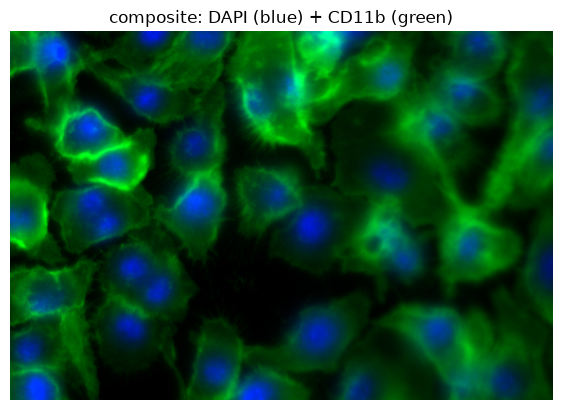

In [8]:
# A composite: put each channel in a colour and stack them into an RGB image.
composite = np.zeros((*nuclei.shape, 3), dtype=np.uint8)
composite[..., 2] = nuclei   # blue channel  <- DAPI
composite[..., 1] = cells    # green channel <- CD11b

plt.figure(figsize=(7, 5))
plt.imshow(composite)
plt.axis("off")
plt.title("composite: DAPI (blue) + CD11b (green)")
plt.show()

That is all `Image ▸ Color ▸ Merge Channels…` does. An RGB image is an array with
one extra axis of length 3, and assigning a channel into it is one line.

## 5. The histogram

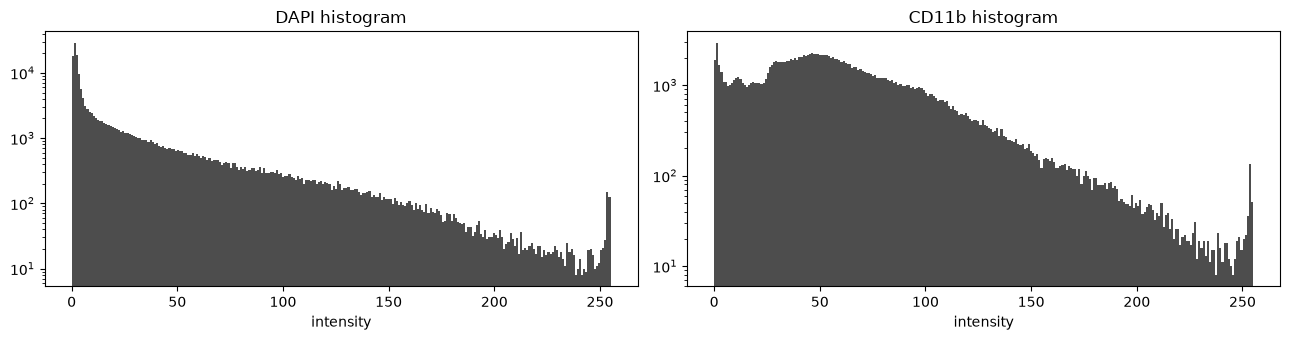

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, img, name in zip(axes, [nuclei, cells], ["DAPI", "CD11b"]):
    ax.hist(img.ravel(), bins=256, range=(0, 255), color="0.3")
    ax.set_yscale("log")
    ax.set_title(f"{name} histogram")
    ax.set_xlabel("intensity")
plt.tight_layout()
plt.show()

The histogram counts how many pixels hold each intensity. Note the log scale on
the y-axis: without it the background peak is so tall that everything else is
invisible.

Both histograms have a large spike near zero: that is background, and most of the
image is background. To the right of it sits a long tail of brighter pixels: the
objects. **Thresholding is the act of drawing a line between those two parts.**

## 6. From intensity image to binary image: semantic segmentation

mask dtype: bool
foreground: 16.3% of pixels


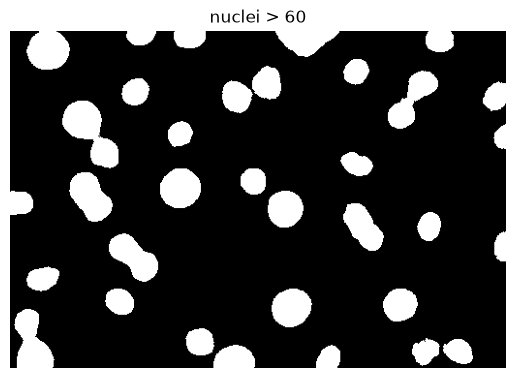

In [10]:
# A threshold produces a boolean array: True where the condition holds.
mask = nuclei > 60

print("mask dtype:", mask.dtype)
print("foreground:", f"{mask.mean() * 100:.1f}% of pixels")

show(mask, title="nuclei > 60")
plt.show()

`nuclei > 60` compares every pixel at once and returns an array of `True`/`False`
: a **mask**. This is Fiji's `Image ▸ Adjust ▸ Threshold…` with the slider at 60,
and picking that number by hand is just as arbitrary here as it was there.

This step has a name. **Semantic segmentation** answers the
question *"what kind of thing is this pixel?"*: here, nucleus or background. It
labels every pixel with a class, and says nothing whatsoever about objects.

Otsu's method picks the threshold automatically, by finding the value that best
separates the histogram into two groups.

Otsu threshold: 61


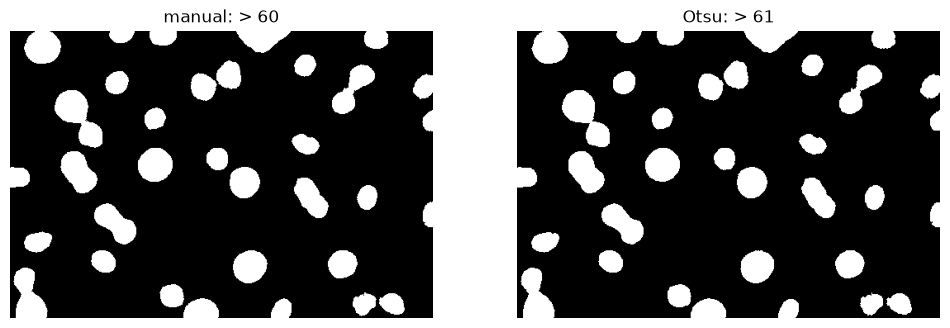

In [11]:
from skimage.filters import threshold_otsu

t = threshold_otsu(nuclei)
print("Otsu threshold:", t)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
show(nuclei > 60, title="manual: > 60", ax=axes[0])
show(nuclei > t, title=f"Otsu: > {t}", ax=axes[1])
plt.show()

### Four kinds of image

These names are used consistently across the bioimage analysis literature, and
the differences between them matter for the rest of the course.

| | what a pixel holds | answers | dtype |
|---|---|---|---|
| **intensity image** | a measured brightness | how much signal is here? | integer or float |
| **binary image** | one of two values | is this pixel foreground? | `bool`, or 0 and 255 |
| **label image** | an object number | *which* object is this pixel in? | integer |
| **probability map** | a number from 0 to 1 | how confident is the classifier? | float |

The first was the starting point and the second has just been made. The third is
the subject of the next section. The fourth appears on day 2, when a classifier
reports how sure it is rather than committing to an answer.

The distinction that trips people up is binary versus label. A binary image
covering twenty nuclei and one covering a single enormous nucleus are
indistinguishable as data: both are just foreground in some places.

```{note}
When a binary image is used to *select* pixels from another image, as in
`image[binary]`, it is often called a **mask**. That is the same array in a
different role, and both words are common.
```

## 7. From binary image to objects: connected component labeling

The mask says *where* the foreground is, but not *how many* things are there. To
count them, the foreground pixels have to be grouped into objects.

The simplest rule: **pixels that touch belong to the same object.** Every
connected group of foreground pixels gets its own number. That is **connected
component labeling**, and it is the first route from a semantic segmentation to
an **instance segmentation**, which answers *"which object is this pixel part
of?"*.

In [12]:
from skimage.measure import label

labels = label(nuclei > t)
print("objects found:", labels.max())

# A label image is NOT a binary image: pixel values are object numbers.
print("label image dtype:", labels.dtype, "| values 0 to", labels.max())

objects found: 34
label image dtype: int32 | values 0 to 34


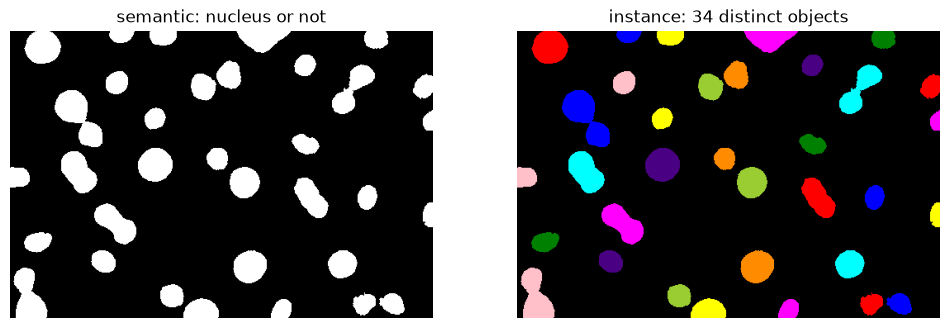

In [13]:
from skimage.color import label2rgb

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
show(nuclei > t, title="semantic: nucleus or not", ax=axes[0])
axes[1].imshow(label2rgb(labels, bg_label=0)); axes[1].set_axis_off()
axes[1].set_title(f"instance: {labels.max()} distinct objects")
plt.show()

Same pixels, two different questions answered. Anything measured per object,
area, shape, or the mean intensity of *this* cell, needs the right-hand one.

This is `Analyze ▸ Analyze Particles…` from the Fiji practical, in three lines, and
unlike the Fiji version it takes a `for` loop around it.

In [14]:
# These images come with expert annotations. Day 2 is all about comparing
# against them properly; for now, just count.
truth = tifffile.imread(DATA / "bbbc020" / "gt" / "2h_1_nuclei_labels.tif")

print("connected components:", labels.max(), "objects")
print("annotated truth     :", truth.max(), "nuclei")

connected components: 34 objects
annotated truth     : 39 nuclei


The automated count is **lower** than the annotated count. Inspect the labels
to see where objects have merged.

The reason is built into the rule we just used. "Pixels that touch belong to the
same object" is a good definition right up until two nuclei touch each other.
Then every pixel between them is foreground, the two form one connected region,
and they are counted once. Each such pair costs one nucleus from the count.

**Connected components cannot separate objects that touch.** No threshold value
fixes this, because as far as the binary image is concerned they really are one region.
That is a limitation of the *method*, not a mistake in the parameters, and it is
why `02_image_processing` introduces a second way of getting from a semantic
segmentation to an instance segmentation.

Check a count against the image or an annotation before using it in an analysis.

## 8. Viewing images interactively

[[13 12 11 ...  5  7  7]
 [15 13 12 ...  5  6  7]
 [16 15 13 ...  5  6  7]
 ...
 [25 29 33 ...  0  0  0]
 [25 28 33 ...  1  0  0]
 [25 28 32 ...  0  0  0]]
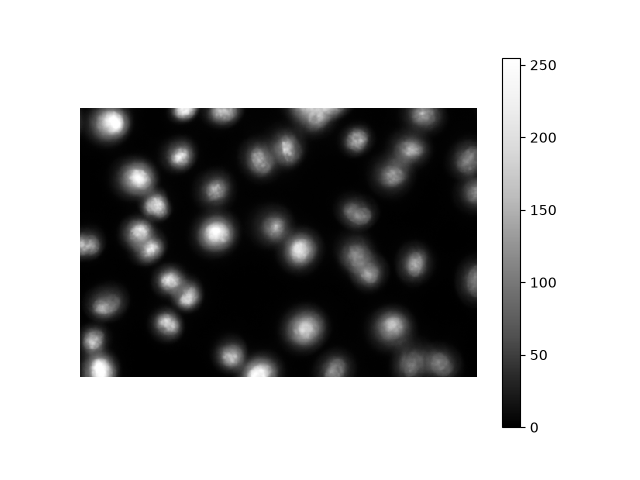
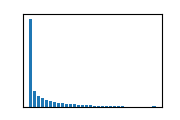

In [15]:
import stackview

# Drag to pan, scroll to zoom, and read pixel values under the cursor.
stackview.insight(nuclei)

In [ ]:
# napari opens a separate window with more tools - useful for anything 3D or
# multi-channel. Run this cell yourself; it is skipped when the website is built.
import napari

viewer = napari.Viewer()
viewer.add_image(nuclei, name="DAPI", colormap="blue", blending="additive")
viewer.add_image(cells, name="CD11b", colormap="green", blending="additive")
viewer.add_labels(labels, name="nuclei labels")

## Recap

These steps correspond to operations from the Fiji practical:

| Fiji | Python |
|---|---|
| open an image | `tifffile.imread(...)` |
| `Image ▸ Type` | `image.dtype` |
| rectangle + `Image ▸ Crop` | `image[90:200, 180:330]` |
| `Analyze ▸ Plot Profile` | `plt.plot(image[150, :])` |
| `Merge Channels…` | assign into an RGB array |
| `Analyze ▸ Histogram` | `plt.hist(image.ravel(), bins=256)` |
| `Adjust ▸ Threshold…` | `image > t`: a semantic segmentation |
| `Analyze Particles…` | `label(mask)`: connected component labeling, an instance segmentation |

The Python version records each operation as code. You can rerun it, review the
parameters and apply it to a folder of images.

Two ideas to carry forward, because everything from here builds on them:

- **semantic** segmentation labels pixels by class; **instance** segmentation
  labels them by object;
- **connected component labeling** turns the first into the second, and fails
  exactly when objects touch.

Next: `02_image_processing` covers preprocessing and watershed segmentation for
touching objects.